# Trade-Level EDA


## Understand the Data


### Load the files


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from config import USER_DATA_PATH, USER_TRADES_PATH

traders_path = os.path.join(USER_DATA_PATH, "Campaign 33 Data 24 Feb 2026 Traders only (1D).xlsx")
trades_path = os.path.join(USER_TRADES_PATH, "Campaign 33 Data 24 Feb 2026 XAUUSD only (1D).csv")

traders = pd.read_excel(traders_path)
trades = pd.read_csv(trades_path)

### Check the shape


In [2]:
print("Traders shape: ", traders.shape)
print("Trades shape: ", trades.shape)

Traders shape:  (500, 3)
Trades shape:  (749, 25)


In [3]:
print(traders.head())

     ACCOUNT                         EMAIL       IP ADDRESS
0  D#1614601  jahanzaibkhalid154@gmail.com  182.185.152.215
1  D#1702708       muh.irwanto99@gmail.com   13.215.129.254
2  D#1702434          xbiswas598@gmail.com    77.111.246.27
3  D#1702729     Wachirajames817@gmail.com   102.210.40.114
4  D#1702577        naziahell988@gmail.com   37.111.148.168


In [4]:
print(trades.head())

   accountId instrument  lotSize         closeTradeId           positionId  \
0  D#1645625     XAUUSD      100  7349874591903930241  7349874591885628592   
1  D#1702379     XAUUSD      100  7349874591903930511  7349874591885628953   
2  D#1645651     XAUUSD      100  7349874591903930537  7349874591885628946   
3  D#1670922     XAUUSD      100  7349874591903930937  7349874591885629157   
4  D#1702617     XAUUSD      100  7349874591903931087  7349874591885629132   

          closeOrderId          openOrderId  durationSec  \
0  7349874591964660940  7349874591964660912          631   
1  7349874591964663694  7349874591964663408           19   
2  7349874591964663739  7349874591964663378           29   
3  7349874591964665237  7349874591964665058           38   
4  7349874591964665786  7349874591964664896          208   

               openDateTime             closeDateTime  ...  amount  openPrice  \
0  2026-02-24T00:49:38.000Z  2026-02-24T01:00:09.000Z  ...    0.04    5229.60   
1  2026-

### Check the column names


In [5]:
print("Traders columns: ", traders.columns.tolist())
print("\nTrades columns: ", trades.columns.tolist())

Traders columns:  ['ACCOUNT', 'EMAIL', 'IP ADDRESS']

Trades columns:  ['accountId', 'instrument', 'lotSize', 'closeTradeId', 'positionId', 'closeOrderId', 'openOrderId', 'durationSec', 'openDateTime', 'closeDateTime', 'profit', 'reverseProfit', 'netProfit', 'commission', 'swap', 'amount', 'openPrice', 'closePrice', 'slPrice', 'tpPrice', 'side', 'currency', 'openTradeCrossPrice', 'closeTradeCrossPrice', 'userGroupId']


### Rename the columns


In [6]:
traders = traders.rename(
    columns={
        "ACCOUNT": "accountId",
        "EMAIL": "email",
        "IP ADDRESS": "ipAddress",
    }
)

print(traders.columns.tolist())

['accountId', 'email', 'ipAddress']


### Check the data type


In [7]:
print("Trader data types:\n", traders.dtypes.to_frame("dtype"))
print("\nTrade data types:\n", trades.dtypes.to_frame("dtype"))

Trader data types:
           dtype
accountId   str
email       str
ipAddress   str

Trade data types:
                         dtype
accountId                 str
instrument                str
lotSize                 int64
closeTradeId            int64
positionId              int64
closeOrderId            int64
openOrderId             int64
durationSec             int64
openDateTime              str
closeDateTime             str
profit                float64
reverseProfit         float64
netProfit             float64
commission            float64
swap                    int64
amount                float64
openPrice             float64
closePrice            float64
slPrice               float64
tpPrice               float64
side                      str
currency                  str
openTradeCrossPrice     int64
closeTradeCrossPrice    int64
userGroupId             int64


### Convert to datetime


In [8]:
trades["openDateTime"] = pd.to_datetime(
    trades["openDateTime"],
    errors="coerce"
)

trades["closeDateTime"] = pd.to_datetime(
    trades["closeDateTime"],
    errors="coerce"
)

print(trades[["openDateTime", "closeDateTime"]].dtypes)

openDateTime     datetime64[us, UTC]
closeDateTime    datetime64[us, UTC]
dtype: object


In [9]:
print("Traders unique account: ", traders["accountId"].nunique())
print("Trades unique account: ", trades["accountId"].nunique())

Traders unique account:  500
Trades unique account:  137


In [10]:
print("Traders duplicated rows: ", traders.duplicated().sum())
print("Trades duplicated rows: ", trades.duplicated().sum())

Traders duplicated rows:  0
Trades duplicated rows:  0


In [11]:
print("Earliest trade opened: ", trades["openDateTime"].min())
print("Latest trade opened: ", trades["openDateTime"].max())
print("Earliest trade closed: ", trades["closeDateTime"].min())
print("Latest trade closed: ", trades["closeDateTime"].max())

Earliest trade opened:  2026-02-24 00:49:38+00:00
Latest trade opened:  2026-02-25 05:28:28+00:00
Earliest trade closed:  2026-02-24 01:00:09+00:00
Latest trade closed:  2026-02-25 05:44:20+00:00


In [12]:
registered_accounts = set(traders["accountId"])
trading_accounts = set(trades["accountId"])

print("Registered traders: ", len(registered_accounts))
print("Accounts with XAUUSD trades: ", len(trading_accounts))

print("Registered but no trades: ", len(registered_accounts - trading_accounts))
print("Trade accounts missing from trader file: ", len(trading_accounts - registered_accounts))

Registered traders:  500
Accounts with XAUUSD trades:  137
Registered but no trades:  366
Trade accounts missing from trader file:  3


In [13]:
missing_accounts = trading_accounts - registered_accounts
print("Missing accounts: ", missing_accounts)
for a in missing_accounts:
    print(f"\n{traders[traders["accountId"] == a]}")

Missing accounts:  {'D#1645625', 'D#1645639', 'D#1759507'}

Empty DataFrame
Columns: [accountId, email, ipAddress]
Index: []

Empty DataFrame
Columns: [accountId, email, ipAddress]
Index: []

Empty DataFrame
Columns: [accountId, email, ipAddress]
Index: []


In [14]:
registered_without_trades = traders[
    ~traders["accountId"].isin(trades["accountId"])
]

trades_without_registration = trades[
    ~trades["accountId"].isin(traders["accountId"])
]

print("Registered without trades: \n", registered_without_trades.head())
print("\nTrades without registration: \n", trades_without_registration.head())

Registered without trades: 
     accountId                         email        ipAddress
0   D#1614601  jahanzaibkhalid154@gmail.com  182.185.152.215
2   D#1702434          xbiswas598@gmail.com    77.111.246.27
3   D#1702729     Wachirajames817@gmail.com   102.210.40.114
9   D#1702453           mjdm56366@gmail.com     41.98.86.235
12  D#1645644   manvithshetty2006@gmail.com   18.142.196.142

Trades without registration: 
      accountId instrument  lotSize         closeTradeId           positionId  \
0    D#1645625     XAUUSD      100  7349874591903930241  7349874591885628592   
147  D#1645639     XAUUSD      100  7349874591903941973  7349874591885634681   
477  D#1759507     XAUUSD      100  7349874591903962154  7349874591885640637   
563  D#1645625     XAUUSD      100  7349874591903967868  7349874591885634384   
565  D#1645625     XAUUSD      100  7349874591903967890  7349874591885630685   

            closeOrderId          openOrderId  durationSec  \
0    7349874591964660940  7349

In [15]:
# Summary
print("Registered traders: ", traders["accountId"].nunique())
print("Raw trade rows: ", len(trades))
print("Unique positions: ", trades["positionId"].nunique())
print("Unique close trades: ", trades["closeTradeId"].nunique())
print("Unique open orders: ", trades["openOrderId"].nunique())
print("Buy rows: ", (trades["side"].str.upper() == "BUY").sum())
print("Sell rows: ", (trades["side"].str.upper() == "SELL").sum())
print("Earliest open: ", trades["openDateTime"].min())
print("Latest close: ", trades["closeDateTime"].max())

Registered traders:  500
Raw trade rows:  749
Unique positions:  749
Unique close trades:  749
Unique open orders:  749
Buy rows:  464
Sell rows:  285
Earliest open:  2026-02-24 00:49:38+00:00
Latest close:  2026-02-25 05:44:20+00:00


## Validate the Unit of Observation


### Check the number of rows per position


In [16]:
rows_per_position = (
    trades.groupby("positionId")
    .size()
    .value_counts()
    .sort_index()
    .rename_axis("rows_per_position")
    .to_frame("number_of_positions")
)

print(rows_per_position)

                   number_of_positions
rows_per_position                     
1                                  749


### Check if all identifiers agree


In [17]:
id_check = pd.DataFrame({
    "identifier": [
        "closeTradeId",
        "positionId",
        "openOrderId",
        "closeOrderId"
    ],
    "non_missing": [
        trades["closeTradeId"].notna().sum(),
        trades["positionId"].notna().sum(),
        trades["openOrderId"].notna().sum(),
        trades["closeOrderId"].notna().sum(),
    ],
    "unique__values": [
        trades["closeTradeId"].nunique(),
        trades["positionId"].nunique(),
        trades["openOrderId"].nunique(),
        trades["closeOrderId"].nunique(),
    ],
    "duplicate_count": [
        trades["closeTradeId"].duplicated().sum(),
        trades["positionId"].duplicated().sum(),
        trades["openOrderId"].duplicated().sum(),
        trades["closeOrderId"].duplicated().sum(),
    ]
})

print(id_check)

     identifier  non_missing  unique__values  duplicate_count
0  closeTradeId          749             749                0
1    positionId          749             749                0
2   openOrderId          749             749                0
3  closeOrderId          749             749                0


### Check missing values


In [18]:
missing_summary = pd.DataFrame({
    "missing_count": trades.isna().sum(),
    "missing_percent": (trades.isna().mean() * 100).round(2)
}).sort_values("missing_percent", ascending=False)

print(missing_summary)

                      missing_count  missing_percent
slPrice                         391            52.20
tpPrice                         275            36.72
accountId                         0             0.00
commission                        0             0.00
closeTradeCrossPrice              0             0.00
openTradeCrossPrice               0             0.00
currency                          0             0.00
side                              0             0.00
closePrice                        0             0.00
openPrice                         0             0.00
amount                            0             0.00
swap                              0             0.00
netProfit                         0             0.00
instrument                        0             0.00
reverseProfit                     0             0.00
profit                            0             0.00
closeDateTime                     0             0.00
openDateTime                      0           

In [19]:
trades["hasStopLoss"] = trades["slPrice"].notna()
trades["hasTakeProfit"] = trades["tpPrice"].notna()

### Check categorical values


In [20]:
categorical_columns = [
    "instrument",
    "side",
    "currency",
    "userGroupId"
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(
        trades[col]
        .value_counts(dropna=False)
        .to_frame("count")
    )


--- instrument ---
            count
instrument       
XAUUSD        749

--- side ---
      count
side       
BUY     464
SELL    285

--- currency ---
          count
currency       
USD         749

--- userGroupId ---
             count
userGroupId       
1583663        739
1583664          9
1583665          1


In [21]:
# Standardize text columns
for col in ["instrument", "side", "currency"]:
    trades[col] = (
        trades[col]
        .astype("string")
        .str.strip()
        .str.upper()
    )

# Check again
for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(
        trades[col]
        .value_counts(dropna=False)
        .to_frame("count")
    )


--- instrument ---
            count
instrument       
XAUUSD        749

--- side ---
      count
side       
BUY     464
SELL    285

--- currency ---
          count
currency       
USD         749

--- userGroupId ---
             count
userGroupId       
1583663        739
1583664          9
1583665          1


### Validate timestamps and duration


In [22]:
trades["calculatedDurationSec"] = (
    trades["closeDateTime"] - trades["openDateTime"]
).dt.total_seconds()

trades["durationDifferenceSec"] = (
    trades["durationSec"] - trades["calculatedDurationSec"]
)

print(
    trades[
        [
            "openDateTime",
            "closeDateTime",
            "durationSec",
            "calculatedDurationSec",
            "durationDifferenceSec"
        ]
    ].head()
)

               openDateTime             closeDateTime  durationSec  \
0 2026-02-24 00:49:38+00:00 2026-02-24 01:00:09+00:00          631   
1 2026-02-24 01:02:19+00:00 2026-02-24 01:02:38+00:00           19   
2 2026-02-24 01:02:15+00:00 2026-02-24 01:02:44+00:00           29   
3 2026-02-24 01:07:03+00:00 2026-02-24 01:07:41+00:00           38   
4 2026-02-24 01:06:23+00:00 2026-02-24 01:09:51+00:00          208   

   calculatedDurationSec  durationDifferenceSec  
0                  631.0                    0.0  
1                   19.0                    0.0  
2                   29.0                    0.0  
3                   38.0                    0.0  
4                  208.0                    0.0  


In [23]:
# Summarize the discrepancy
print(
    trades["durationDifferenceSec"]
    .describe()
    .to_frame("duration_difference_seconds")
)

       duration_difference_seconds
count                        749.0
mean                           0.0
std                            0.0
min                            0.0
25%                            0.0
50%                            0.0
75%                            0.0
max                            0.0


## Validate profit fields and numerical values


netProfit = profit + commission + swap


In [24]:
trades["profitReconciliationError"] = (
    trades["netProfit"]
    - (
        trades["profit"]
        + trades["commission"]
        + trades["swap"]
    )
)

print(
    trades["profitReconciliationError"]
    .describe()
    .to_frame("reconciliation_error")
)

       reconciliation_error
count          7.490000e+02
mean           2.035972e-16
std            4.564837e-15
min           -2.842171e-14
25%            0.000000e+00
50%            0.000000e+00
75%            0.000000e+00
max            5.684342e-14


In [25]:
tolerance = 0.01

reconciliation_check = pd.Series({
    "rows_checked": len(trades),
    "exact_or_near_matches": (
        trades["profitReconciliationError"].abs() <= tolerance
    ).sum(),
    "mismatches_over_1_cent": (
        trades["profitReconciliationError"].abs() > tolerance
    ).sum(),
    "maximum_absolute_error": (
        trades["profitReconciliationError"].abs().max()
    )
})

print(reconciliation_check)

rows_checked              7.490000e+02
exact_or_near_matches     7.490000e+02
mismatches_over_1_cent    0.000000e+00
maximum_absolute_error    5.684342e-14
dtype: float64


In [26]:
print(
    trades.loc[
        trades["profitReconciliationError"]
        .abs()
        .sort_values(ascending=False)
        .head(10)
        .index,
        [
            "accountId",
            "positionId",
            "profit",
            "commission",
            "swap",
            "netProfit",
            "profitReconciliationError"
        ]
    ]
)

     accountId           positionId  profit  commission  swap  netProfit  \
241  D#1702463  7349874591885633214  387.03       -6.66     0     380.37   
65   D#1589408  7349874591885632215 -172.86      -15.06     0    -187.92   
564  D#1670978  7349874591885644560 -154.95       -1.76     0    -156.71   
725  D#1670950  7349874591885656480 -219.96       -6.30     0    -226.26   
481  D#1702536  7349874591885643015 -169.20       -5.26     0    -174.46   
325  D#1702529  7349874591885637904  135.15       -5.26     0     129.89   
314  D#1702450  7349874591885638137 -175.48      -14.36     0    -189.84   
692  D#1702617  7349874591885654457  261.60      -14.00     0     247.60   
81   D#1702718  7349874591885632485 -203.30      -13.30     0    -216.60   
47   D#1702666  7349874591885631689  201.32       -9.80     0     191.52   

     profitReconciliationError  
241               5.684342e-14  
65                2.842171e-14  
564              -2.842171e-14  
725               2.842171e-14 

### Check commission and swap distribution


In [27]:
print(
    trades[["commission", "swap"]]
    .describe()
    .T
)

            count      mean       std   min  25%  50%  75%   max
commission  749.0 -5.104032  3.812502 -17.5 -7.0 -3.5 -2.1 -0.36
swap        749.0  0.000000  0.000000   0.0  0.0  0.0  0.0  0.00


In [28]:
cost_sign_check = pd.DataFrame({
    "positive": [
        (trades["commission"] > 0).sum(),
        (trades["swap"] > 0).sum()
    ],
    "zero": [
        (trades["commission"] == 0).sum(),
        (trades["swap"] == 0).sum()
    ],
    "negative": [
        (trades["commission"] < 0).sum(),
        (trades["swap"] < 0).sum()
    ]
}, index=["commission", "swap"])

print(cost_sign_check)

            positive  zero  negative
commission         0     0       749
swap               0   749         0


### Check if reverseProfit = negative of trader profit


In [29]:
trades["reversePlusGrossProfit"] = (
    trades["reverseProfit"] + trades["profit"]
)

trades["reversePlusNetProfit"] = (
    trades["reverseProfit"] + trades["netProfit"]
)

print(
    trades[
        [
            "reversePlusGrossProfit",
            "reversePlusNetProfit"
        ]
    ]
    .describe()
    .T
)

                        count      mean       std   min  25%  50%   75%   max
reversePlusGrossProfit  749.0 -1.020093  0.762774  -3.5 -1.4 -0.7 -0.42 -0.07
reversePlusNetProfit    749.0 -6.124126  4.575276 -21.0 -8.4 -4.2 -2.52 -0.43


In [30]:
# reverseProfit != - profit / netProfit
print(
    trades[
        [
            "accountId",
            "side", 
            "profit",
            "commission",
            "netProfit",
            "reverseProfit",
            "reversePlusGrossProfit",
            "reversePlusNetProfit"
        ]
    ].head(10)
)

   accountId  side  profit  commission  netProfit  reverseProfit  \
0  D#1645625  SELL  107.28       -1.40     105.88        -107.56   
1  D#1702379   BUY    0.47       -0.36       0.11          -0.54   
2  D#1645651  SELL    2.24       -0.36       1.88          -2.31   
3  D#1670922  SELL    1.00       -0.36       0.64          -1.07   
4  D#1702617   BUY    5.52       -1.06       4.46          -5.73   
5  D#1670952  SELL   61.60       -3.50      58.10         -62.30   
6  D#1702513  SELL    3.23       -0.36       2.87          -3.30   
7  D#1670923   BUY   12.70       -3.50       9.20         -13.40   
8  D#1670979  SELL   16.19       -0.36      15.83         -16.26   
9  D#1702376   BUY -220.75       -1.76    -222.51         220.40   

   reversePlusGrossProfit  reversePlusNetProfit  
0                   -0.28                 -1.68  
1                   -0.07                 -0.43  
2                   -0.07                 -0.43  
3                   -0.07                 -0.43  
4

### Create trader and reverse outcome labels


In [31]:
trades["traderWon"] = trades["netProfit"] > 0
trades["reverseWon"] = trades["reverseProfit"] > 0

In [32]:
trades["traderOutcome"] = np.select(
    [
        trades["netProfit"] > 0,
        trades["netProfit"] < 0,
    ],
    [
        "Win",
        "Loss"
    ],
    default="Breakeven"
)

trades["reverseOutcome"] = np.select(
    [
        trades["reverseProfit"] > 0,
        trades["reverseProfit"] < 0,
    ],
    [
        "Win",
        "Loss"
    ],
    default="Breakeven"
)

print("Trader outcomes: \n", trades["traderOutcome"].value_counts(dropna=False).to_frame("number_of_trades"))
print("\nReverse outcomes: \n", trades["reverseOutcome"].value_counts(dropna=False).to_frame("number_of_trades"))

Trader outcomes: 
                number_of_trades
traderOutcome                  
Win                         379
Loss                        369
Breakeven                     1

Reverse outcomes: 
                 number_of_trades
reverseOutcome                  
Loss                         412
Win                          337


### Basic numerical validity check


In [33]:
numerical_validity = pd.Series({
    "amount_less_than_or_equal_to_zero": (trades["amount"] <= 0).sum(),
    "lotSize_less_than_or_equal_to_zero": (trades["lotSize"] <= 0).sum(),
    "openPrice_less_than_or_equal_to_zero": (trades["openPrice"] <= 0).sum(),
    "closePrice_less_than_or_equal_to_zero": (trades["closePrice"] <= 0).sum(),
    "negative_duration": (trades["durationSec"] < 0).sum(),
    "zero_duration": (trades["durationSec"] == 0).sum(),
    "zero_gross_profit": (trades["profit"] == 0).sum(),
    "zero_net_profit": (trades["netProfit"] == 0).sum(),
    "zero_reverse_profit": (trades["reverseProfit"] == 0).sum(),
    "positive_commission": (trades["commission"] > 0).sum(),
})

print(numerical_validity)

amount_less_than_or_equal_to_zero        0
lotSize_less_than_or_equal_to_zero       0
openPrice_less_than_or_equal_to_zero     0
closePrice_less_than_or_equal_to_zero    0
negative_duration                        0
zero_duration                            0
zero_gross_profit                        2
zero_net_profit                          1
zero_reverse_profit                      0
positive_commission                      0
dtype: int64


In [34]:
print(
    trades.loc[
        (trades["profit"] == 0)
        | (trades["netProfit"] == 0),
        [
            "accountId",
            "positionId",
            "openDateTime",
            "closeDateTime",
            "side",
            "amount",
            "openPrice",
            "closePrice",
            "profit",
            "commission",
            "netProfit",
            "reverseProfit"
        ]
    ]
)

     accountId           positionId              openDateTime  \
15   D#1670941  7349874591885630154 2026-02-24 01:28:00+00:00   
29   D#1670941  7349874591885630951 2026-02-24 01:56:03+00:00   
632  D#1702617  7349874591885652165 2026-02-24 18:05:05+00:00   

                closeDateTime  side  amount  openPrice  closePrice  profit  \
15  2026-02-24 01:28:20+00:00   BUY     0.1    5164.37     5164.50     3.5   
29  2026-02-24 01:58:12+00:00   BUY     0.4    5168.76     5168.54     0.0   
632 2026-02-24 18:10:43+00:00  SELL     0.1    5167.21     5167.43     0.0   

     commission  netProfit  reverseProfit  
15         -3.5        0.0           -4.2  
29        -14.0      -14.0           -2.8  
632        -3.5       -3.5           -0.7  


### Check `lotSize` and `amount`


In [35]:
print(
    trades[["lotSize", "amount"]]
    .describe()
    .T
)

         count        mean       std     min     25%    50%    75%    max
lotSize  749.0  100.000000  0.000000  100.00  100.00  100.0  100.0  100.0
amount   749.0    0.145728  0.108968    0.01    0.06    0.1    0.2    0.5


In [36]:
# Summary
profit_validation_summary = pd.Series({
    "total_rows": len(trades),
    "net_profit_formula_mismatches": (
        trades["profitReconciliationError"].abs() > 0.01
    ).sum(),
    "mean_trader_net_profit": trades["netProfit"].mean(),
    "median_trader_net_profit": trades["netProfit"].median(),
    "total_trader_net_profit": trades["netProfit"].sum(),
    "mean_reverse_profit": trades["reverseProfit"].mean(),
    "median_reverse_profit": trades["reverseProfit"].median(),
    "total_reverse_profit": trades["reverseProfit"].sum(),
    "trader_win_rate": trades["traderWon"].mean(),
    "reverse_win_rate": trades["reverseWon"].mean()
})

print(
    profit_validation_summary
)

total_rows                        749.000000
net_profit_formula_mismatches       0.000000
mean_trader_net_profit             -8.044860
median_trader_net_profit            0.470000
total_trader_net_profit         -6025.600000
mean_reverse_profit                 1.920734
median_reverse_profit              -3.300000
total_reverse_profit             1438.630000
trader_win_rate                     0.506008
reverse_win_rate                    0.449933
dtype: float64


## Distribution and Outlier Analysis


### Descriptive statistics


In [37]:
key_numeric_columns = [
    "netProfit",
    "reverseProfit",
    "amount",
    "durationSec"
]

distribution_summary = trades[key_numeric_columns].describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99
    ]
).T

print(distribution_summary)

               count         mean          std     min        1%       5%  \
netProfit      749.0    -8.044860    97.205608 -365.20 -300.2008 -189.072   
reverseProfit  749.0     1.920734    97.064232 -486.40 -281.6088 -125.040   
amount         749.0     0.145728     0.108968    0.01    0.0100    0.010   
durationSec    749.0  2237.068091  7035.697323    2.00    6.4800   19.000   

                  25%     50%      75%       95%         99%      max  
netProfit      -46.50    0.47    43.84    117.48    265.3800    469.6  
reverseProfit  -51.15   -3.30    40.02    175.90    294.4240    356.8  
amount           0.06    0.10     0.20      0.40      0.4552      0.5  
durationSec    102.00  333.00  1231.00  11389.60  33192.9600  79210.0  


### Compare mean and median


In [38]:
mean_median_summary = pd.DataFrame({
    "mean": trades[key_numeric_columns].mean(),
    "median": trades[key_numeric_columns].median(),
    "min": trades[key_numeric_columns].min(),
    "max": trades[key_numeric_columns].max(),
})

print(mean_median_summary)

                      mean  median     min      max
netProfit        -8.044860    0.47 -365.20    469.6
reverseProfit     1.920734   -3.30 -486.40    356.8
amount            0.145728    0.10    0.01      0.5
durationSec    2237.068091  333.00    2.00  79210.0


### Plot trader net profit distribution


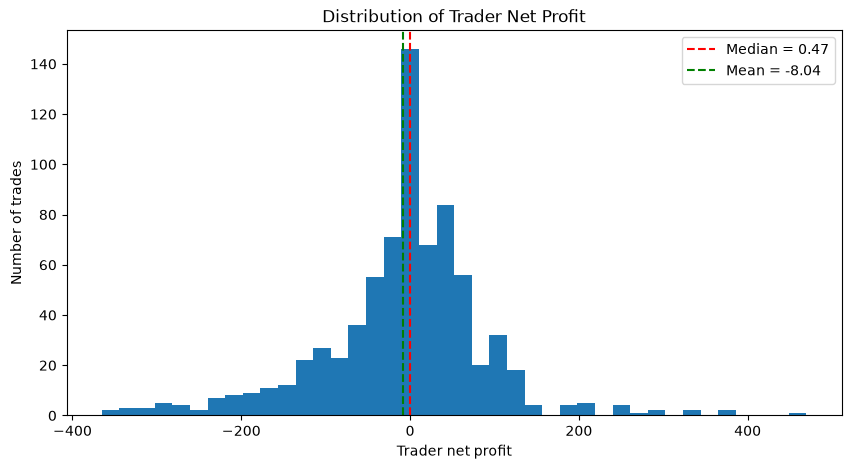

In [39]:
plt.figure(figsize=(10, 5))

plt.hist(
    trades["netProfit"],
    bins=40
)

plt.axvline(
    trades["netProfit"].median(),
    linestyle="--",
    label=f"Median = {trades['netProfit'].median():.2f}",
    color="red"
)

plt.axvline(
    trades["netProfit"].mean(),
    linestyle="--",
    label=f"Mean = {trades['netProfit'].mean():.2f}",
    color="green"
)

plt.xlabel("Trader net profit")
plt.ylabel("Number of trades")
plt.title("Distribution of Trader Net Profit")
plt.legend()
plt.show()

### Plot reverse profit distribution


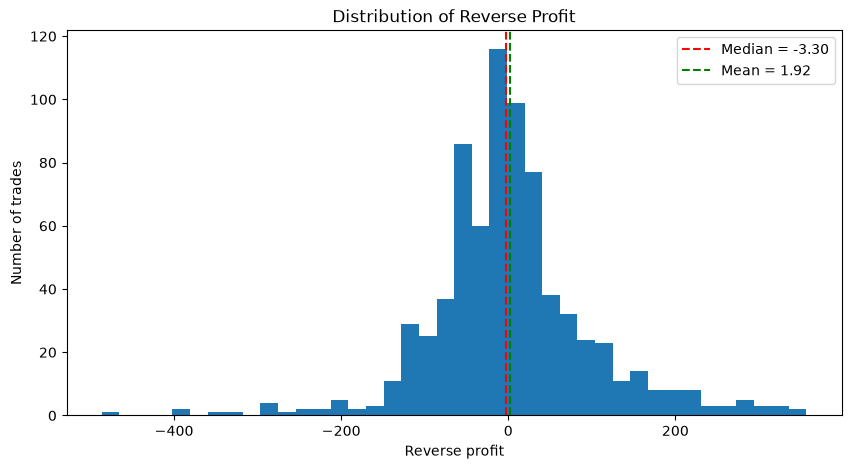

In [40]:
plt.figure(figsize=(10, 5))

plt.hist(
    trades["reverseProfit"],
    bins=40
)

plt.axvline(
    trades["reverseProfit"].median(),
    linestyle="--",
    label=f"Median = {trades['reverseProfit'].median():.2f}",
    color="red"
)

plt.axvline(
    trades["reverseProfit"].mean(),
    linestyle="--",
    label=f"Mean = {trades['reverseProfit'].mean():.2f}",
    color="green"
)

plt.xlabel("Reverse profit")
plt.ylabel("Number of trades")
plt.title("Distribution of Reverse Profit")
plt.legend()
plt.show()

### Plot position-size distribution


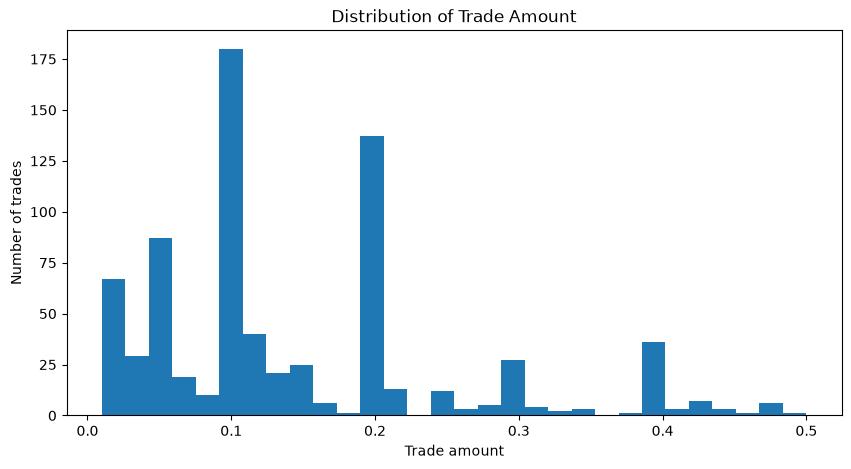

In [41]:
plt.figure(figsize=(10, 5))

plt.hist(
    trades["amount"],
    bins=30
)

plt.xlabel("Trade amount")
plt.ylabel("Number of trades")
plt.title("Distribution of Trade Amount")
plt.show()

In [42]:
amount_frequency = (
    trades["amount"]
    .value_counts()
    .sort_index()
    .to_frame("number_of_trades")
)

print(amount_frequency)

        number_of_trades
amount                  
0.01                  51
0.02                  16
0.03                  15
0.04                  14
0.05                  87
0.06                   9
0.07                  10
0.08                   6
0.09                   4
0.10                 180
0.11                  11
0.12                  29
0.13                  13
0.14                   8
0.15                  25
0.16                   4
0.17                   2
0.18                   1
0.19                   9
0.20                 128
0.21                   9
0.22                   4
0.24                   3
0.25                   9
0.26                   1
0.27                   2
0.28                   5
0.29                   1
0.30                  26
0.31                   1
0.32                   3
0.33                   2
0.35                   3
0.38                   1
0.40                  36
0.41                   3
0.42                   1
0.43                   6


### Convert duration into more understandable units


In [43]:
trades["durationMin"] = trades["durationSec"] / 60
trades["durationHour"] = trades["durationSec"] / 3600

print(
    trades[
        [
            "durationSec",
            "durationMin",
            "durationHour",
        ]
    ].describe(
        percentiles=[
            0.25, 
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    ).T
)

              count         mean          std       min         25%       50%  \
durationSec   749.0  2237.068091  7035.697323  2.000000  102.000000  333.0000   
durationMin   749.0    37.284468   117.261622  0.033333    1.700000    5.5500   
durationHour  749.0     0.621408     1.954360  0.000556    0.028333    0.0925   

                      75%          90%           95%           99%  \
durationSec   1231.000000  4283.200000  11389.600000  33192.960000   
durationMin     20.516667    71.386667    189.826667    553.216000   
durationHour     0.341944     1.189778      3.163778      9.220267   

                       max  
durationSec   79210.000000  
durationMin    1320.166667  
durationHour     22.002778  


### Plot duration distribution


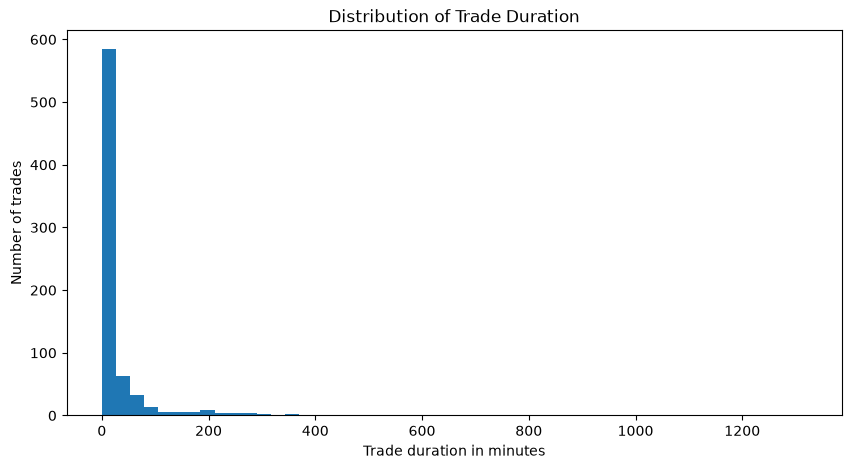

In [44]:
plt.figure(figsize=(10, 5))

plt.hist(
    trades["durationMin"],
    bins=50
)

plt.xlabel("Trade duration in minutes")
plt.ylabel("Number of trades")
plt.title("Distribution of Trade Duration")
plt.show()

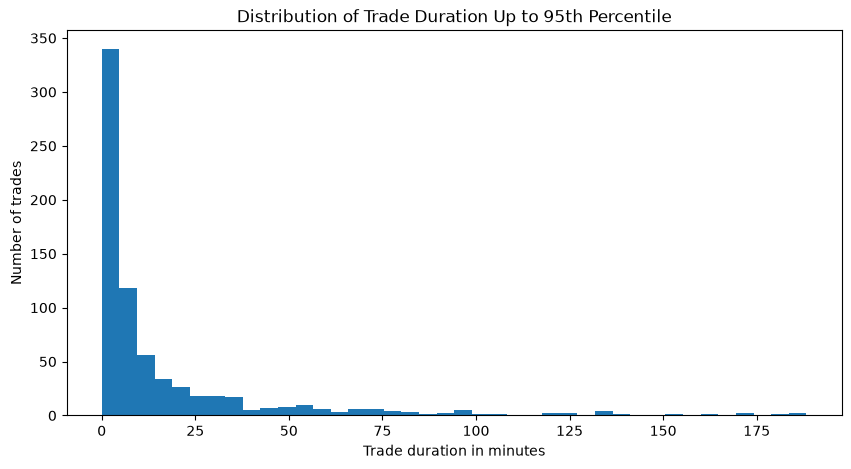

In [45]:
# Zoom in on the first 95%
duration_95 = trades["durationMin"].quantile(0.95)

plt.figure(figsize=(10, 5))

plt.hist(
    trades.loc[
        trades["durationMin"] <= duration_95,
        "durationMin"
    ],
    bins=40
)

plt.xlabel("Trade duration in minutes")
plt.ylabel("Number of trades")
plt.title("Distribution of Trade Duration Up to 95th Percentile")
plt.show()

In [46]:
duration_bins = [
    -np.inf, 
    30, 
    60, 
    300,
    900, 
    3600,
    14400,
    np.inf
]

duration_labels = [
    "Under 30 sec",
    "30 sec-1 min",
    "1-5 min",
    "5-15 min",
    "15-60 min",
    "1-4 hour",
    "Over 4 hours"
]

trades["durationBucket"] = pd.cut(
    trades["durationSec"],
    bins=duration_bins,
    labels=duration_labels
)

duration_bucket_summary = (
    trades["durationBucket"]
    .value_counts(sort=False)
    .to_frame("number_of_trades")
)

duration_bucket_summary["percentage"] = (
    duration_bucket_summary["number_of_trades"] 
    / len(trades) 
    * 100
)

print(duration_bucket_summary)

                number_of_trades  percentage
durationBucket                              
Under 30 sec                  71    9.479306
30 sec-1 min                  57    7.610147
1-5 min                      219   29.238985
5-15 min                     176   23.497997
15-60 min                    139   18.558077
1-4 hour                      60    8.010681
Over 4 hours                  27    3.604806


### Identify outliers using IQR


In [47]:
def iqr_outlier_summary(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (
        (series < lower_bound) 
        | (series > upper_bound)
    )

    return pd.Series({
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "number_of_outliers": outlier_mask.sum(),
        "outlier_percentage": outlier_mask.mean() * 100
    })

In [48]:
key_numeric_columns = [
    "netProfit",
    "reverseProfit",
    "amount",
    "durationSec"
]

outlier_summary = pd.DataFrame({
    column: iqr_outlier_summary(trades[column])
    for column in key_numeric_columns
}).T

print(outlier_summary)

                   q1       q3      iqr  lower_bound  upper_bound  \
netProfit      -46.50    43.84    90.34     -182.010      179.350   
reverseProfit  -51.15    40.02    91.17     -187.905      176.775   
amount           0.06     0.20     0.14       -0.150        0.410   
durationSec    102.00  1231.00  1129.00    -1591.500     2924.500   

               number_of_outliers  outlier_percentage  
netProfit                    61.0            8.144192  
reverseProfit                57.0            7.610147  
amount                       18.0            2.403204  
durationSec                 109.0           14.552737  


### The largest trader loss


In [49]:
largest_losses = trades.nsmallest(
    10, 
    "netProfit"
)[
    [
        "accountId",
        "positionId",
        "openDateTime",
        "closeDateTime",
        "side",
        "amount",
        "durationMin",
        "openPrice",
        "closePrice",
        "netProfit",
        "reverseProfit",
        "slPrice",
        "tpPrice"
    ]
]

print(largest_losses)

     accountId           positionId              openDateTime  \
480  D#1702535  7349874591885643523 2026-02-24 11:14:21+00:00   
697  D#1702693  7349874591885655139 2026-02-24 20:13:38+00:00   
234  D#1702614  7349874591885636130 2026-02-24 06:10:09+00:00   
479  D#1589428  7349874591885640327 2026-02-24 08:38:11+00:00   
370  D#1702614  7349874591885638316 2026-02-24 07:29:23+00:00   
600  D#1670935  7349874591885650158 2026-02-24 16:56:03+00:00   
482  D#1702663  7349874591885644011 2026-02-24 11:46:51+00:00   
247  D#1702451  7349874591885636205 2026-02-24 06:15:04+00:00   
597  D#1702632  7349874591885644800 2026-02-24 12:18:40+00:00   
745  D#1645639  7349874591885662039 2026-02-25 02:51:32+00:00   

                closeDateTime  side  amount  durationMin  openPrice  \
480 2026-02-24 12:17:22+00:00   BUY    0.20    63.016667    5177.01   
697 2026-02-24 20:24:40+00:00  SELL    0.20    11.033333    5147.15   
234 2026-02-24 06:34:08+00:00   BUY    0.20    23.983333    5183.14   


In [50]:
largest_profits = trades.nlargest(
    10, 
    "netProfit"
)[
    [
        "accountId",
        "positionId",
        "openDateTime",
        "closeDateTime",
        "side",
        "amount",
        "durationMin",
        "openPrice",
        "closePrice",
        "netProfit",
        "reverseProfit",
        "slPrice",
        "tpPrice"
    ]
]

print(largest_profits)

     accountId           positionId              openDateTime  \
54   D#1670941  7349874591885631570 2026-02-24 02:19:14+00:00   
241  D#1702463  7349874591885633214 2026-02-24 03:44:20+00:00   
672  D#1670870  7349874591885653621 2026-02-24 18:56:14+00:00   
742  D#1702636  7349874591885657435 2026-02-24 23:48:10+00:00   
372  D#1671070  7349874591885638650 2026-02-24 07:43:39+00:00   
608  D#1670978  7349874591885647943 2026-02-24 13:53:38+00:00   
579  D#1702528  7349874591885641283 2026-02-24 09:22:51+00:00   
192  D#1702541  7349874591885633836 2026-02-24 04:10:13+00:00   
80   D#1702666  7349874591885632442 2026-02-24 02:59:56+00:00   
591  D#1702635  7349874591885648304 2026-02-24 14:22:46+00:00   

                closeDateTime  side  amount  durationMin  openPrice  \
54  2026-02-24 02:34:10+00:00   BUY    0.40    14.933333    5171.84   
241 2026-02-24 06:35:07+00:00  SELL    0.19   170.783333    5177.40   
672 2026-02-24 19:11:11+00:00  SELL    0.40    14.950000    5161.38   


### Check how much total profit depends on extreme trades


In [51]:
# Calculate total trader P&L
total_trader_profit = trades["netProfit"].sum()

print("Total trader net profit: ", total_trader_profit)

Total trader net profit:  -6025.6


In [52]:
# Remove the single largest winning trade
profit_without_largest_winner = (
    trades["netProfit"].sum()
    - trades["netProfit"].max()
)

print("Trader P&L excluding largest winning trade: ", profit_without_largest_winner)

Trader P&L excluding largest winning trade:  -6495.200000000001


In [53]:
# Check top 5 winning trades
top_5_profit = (
    trades.nlargest(5, "netProfit")["netProfit"].sum()
)

print("Profit from top 5 winning trades: ", top_5_profit)

Profit from top 5 winning trades:  1894.0600000000002


In [54]:
# Calculate their contribution to all positive profits
total_positive_profit = trades.loc[
    trades["netProfit"] > 0,
    "netProfit"
].sum()

top_5_positive_contribution = (
    top_5_profit / total_positive_profit
    if total_positive_profit != 0
    else np.nan
)

print("Top 5 contribution to positive profit: ", f"{top_5_positive_contribution:.2%}")

Top 5 contribution to positive profit:  8.69%


### Boxplots for outlier inspection


/var/folders/j5/5b1mqmv52k34nmgd7y34xqqr0000gn/T/ipykernel_99338/1184304272.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


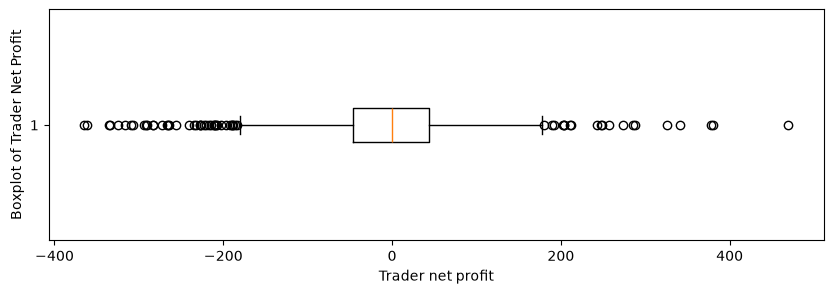

In [55]:
plt.figure(figsize=(10, 3))

plt.boxplot(
    trades["netProfit"],
    vert=False
)

plt.xlabel("Trader net profit")
plt.ylabel("Boxplot of Trader Net Profit")
plt.show()

/var/folders/j5/5b1mqmv52k34nmgd7y34xqqr0000gn/T/ipykernel_99338/79285421.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


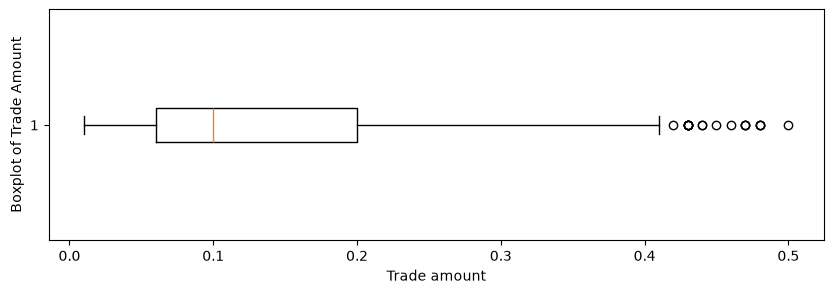

In [56]:
plt.figure(figsize=(10, 3))

plt.boxplot(
    trades["amount"],
    vert=False
)

plt.xlabel("Trade amount")
plt.ylabel("Boxplot of Trade Amount")
plt.show()

/var/folders/j5/5b1mqmv52k34nmgd7y34xqqr0000gn/T/ipykernel_99338/655103423.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


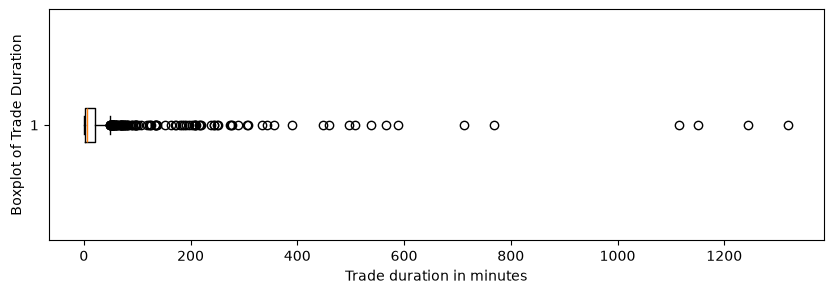

In [57]:
plt.figure(figsize=(10, 3))

plt.boxplot(
    trades["durationMin"],
    vert=False
)

plt.xlabel("Trade duration in minutes")
plt.ylabel("Boxplot of Trade Duration")
plt.show()

### Initial observation

1. Trader and reverse P&L distributions are highly dispersed.
2. Trade duration is strongly right-skewed, with a small number of positions held for many hours.
3. Extremee P&L and amount values will be retained because they may represent meaningful risk-taking behaviour rather than data errors.


## Trader Profit vs Reverse Profit


### Correlation


In [58]:
profit_correlation = trades[
    ["netProfit", "reverseProfit"]
].corr()

print(profit_correlation)

               netProfit  reverseProfit
netProfit       1.000000      -0.998892
reverseProfit  -0.998892       1.000000


### Plot trader profit against reverse profit


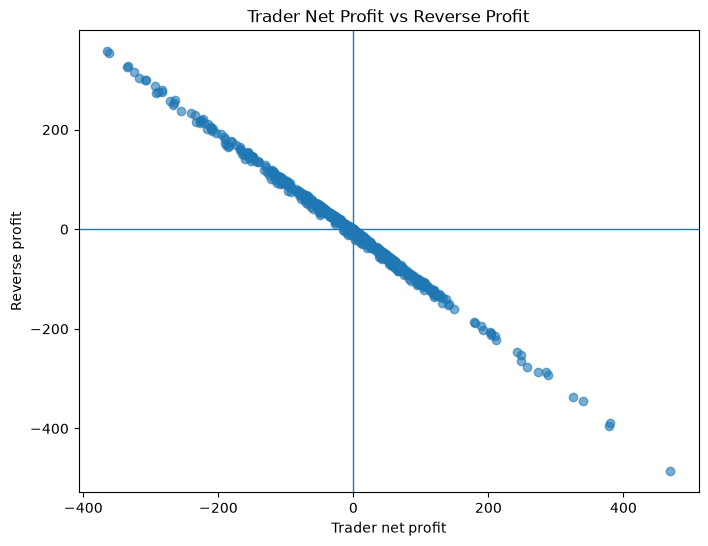

In [59]:
plt.figure(figsize=(8, 6))

plt.scatter(
    trades["netProfit"],
    trades["reverseProfit"],
    alpha=0.6
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Trader net profit")
plt.ylabel("Reverse profit")
plt.title("Trader Net Profit vs Reverse Profit")
plt.show()

### Classify 4 possible outcomes


In [60]:
conditions = [
    (trades["netProfit"] > 0) & (trades["reverseProfit"] > 0),
    (trades["netProfit"] > 0) & (trades["reverseProfit"] <= 0),
    (trades["netProfit"] <= 0) & (trades["reverseProfit"] > 0),
    (trades["netProfit"] <= 0) & (trades["reverseProfit"] <= 0)
]

choices = [
    "Both profitable",
    "Trader profitable, reverse unprofitable",
    "Trader unprofitable, reverse profitable",
    "Both unprofitable"
]

trades["jointOutcome"] = np.select(
    conditions,
    choices,
    default="Unknown"
)

joint_outcome_summary = (
    trades["jointOutcome"]
    .value_counts()
    .to_frame("number_of_trades")
)

joint_outcome_summary["percentage"] = (
    joint_outcome_summary["number_of_trades"]
    / len(trades)
    * 100
)

print(joint_outcome_summary)

                                         number_of_trades  percentage
jointOutcome                                                         
Trader profitable, reverse unprofitable               379   50.600801
Trader unprofitable, reverse profitable               337   44.993324
Both unprofitable                                      33    4.405874


### Measure the cost gap between both sides


In [61]:
trades["twoSidedResidual"] = (
    trades["netProfit"] + trades["reverseProfit"]
)

print(
    trades["twoSidedResidual"]
    .describe()
    .to_frame("two_sided_residual")
)

       two_sided_residual
count          749.000000
mean            -6.124126
std              4.575276
min            -21.000000
25%             -8.400000
50%             -4.200000
75%             -2.520000
max             -0.430000


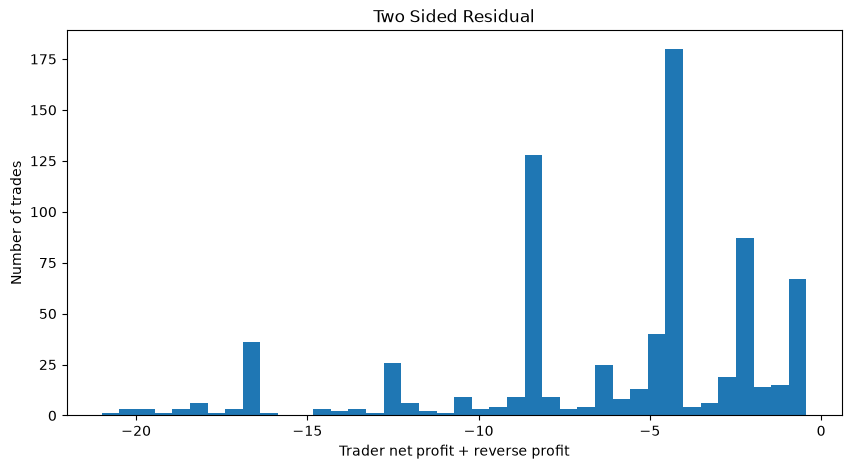

In [62]:
# Plot
plt.figure(figsize=(10, 5))

plt.hist(
    trades["twoSidedResidual"],
    bins=40
)

plt.xlabel("Trader net profit + reverse profit")
plt.ylabel("Number of trades")
plt.title("Two Sided Residual")
plt.show()

In [63]:
# Calculate the average
average_combined_cost = (
    -trades["twoSidedResidual"].mean()
)

print("Two sided residual per trade: ", average_combined_cost)

Two sided residual per trade:  6.124125500667556


### Reverse-every-trade baseline


In [64]:
reverse_baseline = pd.Series({
    "number_of_trades": len(trades),
    "total_reverse_profit": trades["reverseProfit"].sum(),
    "mean_reverse_profit": trades["reverseProfit"].mean(),
    "median_reverse_profit": trades["reverseProfit"].median(),
    "reverse_win_rate": (trades["reverseProfit"] > 0).mean(),
    "largest_reverse_win": trades["reverseProfit"].max(),
    "largest_reverse_loss": trades["reverseProfit"].min()
})

print(reverse_baseline.to_frame("Reverse every trade"))

                       Reverse every trade
number_of_trades                749.000000
total_reverse_profit           1438.630000
mean_reverse_profit               1.920734
median_reverse_profit            -3.300000
reverse_win_rate                  0.449933
largest_reverse_win             356.800000
largest_reverse_loss           -486.400000


### Calculate gross gains and gross losses


In [65]:
reverse_gross_profit = trades.loc[
    trades["reverseProfit"] > 0,
    "reverseProfit"
].sum()

reverse_gross_loss = trades.loc[
    trades["reverseProfit"] < 0,
    "reverseProfit"
].sum()

print("Gross reverse profit: ", reverse_gross_profit)
print("Gross reverse loss: ", reverse_gross_loss)

Gross reverse profit:  25629.28
Gross reverse loss:  -24190.65


### Calculate profit factor


In [66]:
if reverse_gross_loss != 0:
    reverse_profit_factor = (
        reverse_gross_profit
        / abs(reverse_gross_loss)
    )
else:
    reverse_profit_factor = np.nan

print("Reverse profit factor: ", reverse_profit_factor)

Reverse profit factor:  1.0594704978989815


Interpretation:

- Above 1: gross profits exceed gross losses
- Equal to 1: break-even before any additional costs
- Below 1: losses exceed gains


### Calculate average win and average loss


In [67]:
average_reverse_win = trades.loc[
    trades["reverseProfit"] > 0,
    "reverseProfit"
].mean()

average_reverse_loss = trades.loc[
    trades["reverseProfit"] < 0,
    "reverseProfit"
].mean()

print("Average reverse win: ", average_reverse_win)
print("Average reverse loss: ", average_reverse_loss)

Average reverse win:  76.05127596439169
Average reverse loss:  -58.71516990291263


In [68]:
if average_reverse_loss != 0:
    reverse_payoff_ratio = (
        average_reverse_win
        / abs(average_reverse_loss)
    )
else:
    reverse_payoff_ratio = np.nan

print(
    "Reverse payoff ratio:",
    reverse_payoff_ratio
)

Reverse payoff ratio: 1.2952577006954908


### Chronological Reverse-Profit Curve


In [69]:
trades_chronological = trades.sort_values(
    ["openDateTime", "positionId"]
).copy()

In [70]:
trades_chronological["cumulativeReverseProfit"] = (
    trades_chronological["reverseProfit"].cumsum()
)

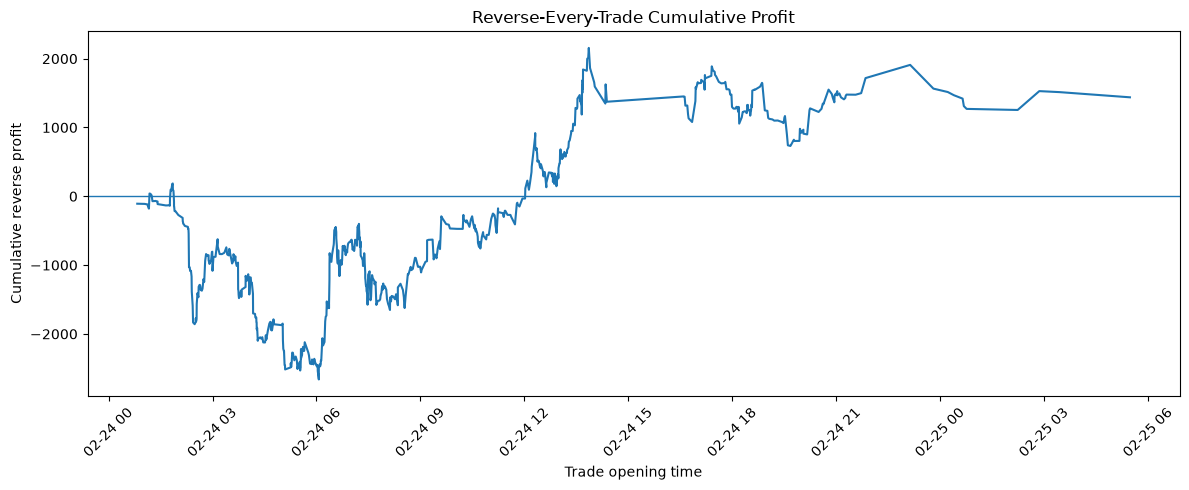

In [71]:
plt.figure(figsize=(12, 5))

plt.plot(
    trades_chronological["openDateTime"],
    trades_chronological["cumulativeReverseProfit"]
)

plt.axhline(0, linewidth=1)

plt.xlabel("Trade opening time")
plt.ylabel("Cumulative reverse profit")
plt.title("Reverse-Every-Trade Cumulative Profit")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Calculate reverse-strategy drawdown


In [72]:
trades_chronological["cumulativeReverseProfit"] = (
    trades_chronological["reverseProfit"].cumsum()
)

trades_chronological["reverseProfitPeak"] = (
    trades_chronological["cumulativeReverseProfit"].cummax()
)

trades_chronological["reverseDrawDown"] = (
    trades_chronological["cumulativeReverseProfit"]
    - trades_chronological["reverseProfitPeak"]
)

In [73]:
maximum_reverse_drawdown = (
    trades_chronological["reverseDrawDown"].min()
)

print("Maximum realised reverse-strategy drawdown: ", maximum_reverse_drawdown)

Maximum realised reverse-strategy drawdown:  -2848.269999999998


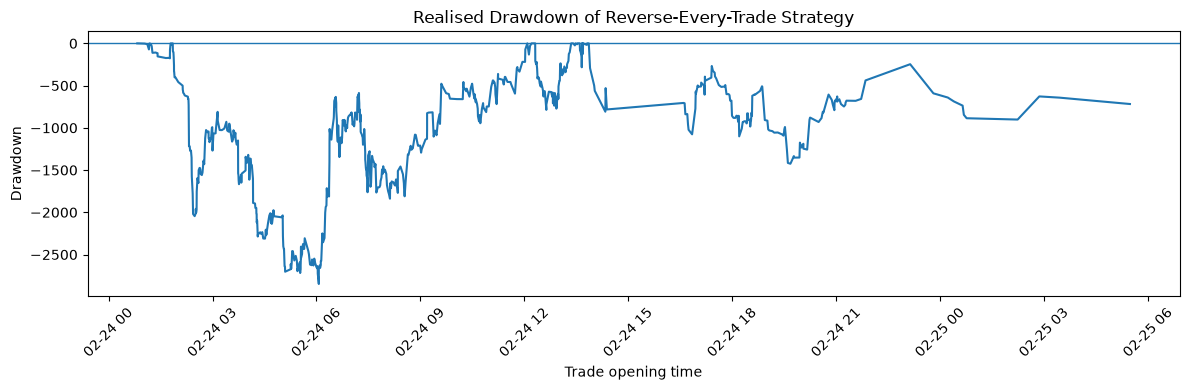

In [74]:
plt.figure(figsize=(12, 4))

plt.plot(
    trades_chronological["openDateTime"],
    trades_chronological["reverseDrawDown"]
)

plt.axhline(0, linewidth=1)

plt.xlabel("Trade opening time")
plt.ylabel("Drawdown")
plt.title("Realised Drawdown of Reverse-Every-Trade Strategy")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Check if extreme trades dominate the baseline


In [75]:
total_positive_reverse_profit = trades.loc[
    trades["reverseProfit"] > 0,
    "reverseProfit"
].sum()

top_5_reverse_wins = trades.nlargest(
    5, 
    "reverseProfit"
)["reverseProfit"].sum()

top_5_reverse_contribution = (
    top_5_reverse_wins
    / total_positive_reverse_profit
    if total_positive_reverse_profit != 0
    else np.nan
)

print("Top 5 reverse winners' contribution: ", f"{top_5_positive_contribution:.2%}")

Top 5 reverse winners' contribution:  8.69%


### Total reverse profit without top 5


In [76]:
reverse_profit_without_top_5 = (
    trades["reverseProfit"].sum()
     - top_5_reverse_wins
)

print("Total reverse profit excluding top 5 wins: ", reverse_profit_without_top_5)

Total reverse profit excluding top 5 wins:  -242.82000000000016


### Total reverse profit without bottom 5


In [77]:
bottom_5_reverse_losses = trades.nsmallest(
    5,
    "reverseProfit"
)["reverseProfit"].sum()

reverse_profit_without_bottom_5 = (
    trades["reverseProfit"].sum()
    - bottom_5_reverse_losses
)

print("Total reverse profit excluding bottom 5 losses: ", reverse_profit_without_bottom_5)

Total reverse profit excluding bottom 5 losses:  3388.99


In [78]:
reverse_baseline_summary = pd.DataFrame({
    "metric": [
        "Number of trades",
        "Total reverse profit",
        "Mean reverse profit",
        "Median reverse profit",
        "Reverse win rate",
        "Gross profit",
        "Gross loss",
        "Profit factor",
        "Average win",
        "Average loss",
        "Payoff ratio",
        "Maximum realised drawdown",
        "Top 5 winner contribution"
    ],
    "value": [
        len(trades),
        trades["reverseProfit"].sum(),
        trades["reverseProfit"].mean(),
        trades["reverseProfit"].median(),
        (trades["reverseProfit"] > 0).mean(),
        reverse_gross_profit,
        reverse_gross_loss,
        reverse_profit_factor,
        average_reverse_win,
        average_reverse_loss,
        reverse_payoff_ratio,
        maximum_reverse_drawdown,
        top_5_reverse_contribution
    ]
})

print(reverse_baseline_summary)

                       metric         value
0            Number of trades    749.000000
1        Total reverse profit   1438.630000
2         Mean reverse profit      1.920734
3       Median reverse profit     -3.300000
4            Reverse win rate      0.449933
5                Gross profit  25629.280000
6                  Gross loss -24190.650000
7               Profit factor      1.059470
8                 Average win     76.051276
9                Average loss    -58.715170
10               Payoff ratio      1.295258
11  Maximum realised drawdown  -2848.270000
12  Top 5 winner contribution      0.065607


### Initial baseline interpretation

The reverse-every-trade strategy is used only as a benchmark. Its total profit, win rate, profit factor and realised drawdown should be interpreted together. Even if Campaign 33 is profitable, the result may be driven by a small number of extreme trades or by market conditions specific to this campaign.


# Account-Level EDA


## Create account-level summary


In [79]:
print("Registered accounts: ", traders["accountId"].nunique())
print("Account with trades: ", trades["accountId"].nunique())

Registered accounts:  500
Account with trades:  137


In [80]:
account_summary = (
    trades.groupby("accountId")
    .agg(
        numberOfTrades=("positionId", "count"),

        totalNetProfit=("netProfit", "sum"),
        meanNetProfit=("netProfit", "mean"),
        medianNetProfit=("netProfit", "median"),

        totalReverseProfit=("reverseProfit", "sum"),
        meanReverseProfit=("reverseProfit", "mean"),
        medianReverseProfit=("reverseProfit", "median"),

        traderWins=("traderWon", "sum"),
        reverseWins=("reverseWon", "sum"),

        meanAmount=("amount", "mean"),
        medianAmount=("amount", "median"),
        maximumAmount=("amount", "max"),

        meanDurationSec=("durationSec", "mean"),
        medianDurationSec=("durationSec", "median"),

        firstTradeTime=("openDateTime", "min"),
        lastTradeTime=("closeDateTime", "max"),
    )
    .reset_index()
)

### Create win rates


In [81]:
account_summary["traderWinRate"] = (
    account_summary["traderWins"]
    / account_summary["numberOfTrades"]
)

account_summary["reverseWinRate"] = (
    account_summary["reverseWins"]
    / account_summary["numberOfTrades"]
)

### Create duration in minutes


In [82]:
account_summary["meanDurationMin"] = (
    account_summary["meanDurationSec"] / 60
)

account_summary["medianDurationMin"] = (
    account_summary["medianDurationSec"] / 60
)

In [83]:
print(account_summary.head())
print("Account summary shape: ", account_summary.shape)

   accountId  numberOfTrades  totalNetProfit  meanNetProfit  medianNetProfit  \
0  D#1589378               1            0.01       0.010000             0.01   
1  D#1589408               3         -254.62     -84.873333           -72.00   
2  D#1589410               2           87.60      43.800000            43.80   
3  D#1589419               1          -20.11     -20.110000           -20.11   
4  D#1589428               3         -213.07     -71.023333            13.00   

   totalReverseProfit  meanReverseProfit  medianReverseProfit  traderWins  \
0               -0.44          -0.440000                -0.44           1   
1              219.75          73.250000                59.40           1   
2              -96.00         -48.000000               -48.00           2   
3               19.68          19.680000                19.68           0   
4              196.25          65.416667               -17.20           2   

   reverseWins  ...  medianAmount  maximumAmount  meanDu

### Validate the aggregation


In [84]:
print(
    "Trade rows before aggregation: ",
    len(trades)
)

print(
    "Trades counted in account summary: ",
    account_summary["numberOfTrades"].sum()
)

print(
    "Unique active accounts:", 
    trades["accountId"].nunique()
)

print(
    "Rows in account summary: ",
    len(account_summary)
)

Trade rows before aggregation:  749
Trades counted in account summary:  749
Unique active accounts: 137
Rows in account summary:  137


### Add registered trader information


In [85]:
all_accounts_summary = traders.merge(
    account_summary,
    on="accountId",
    how="left"
)

### Create active-trader indicator

In [86]:
all_accounts_summary["isActiveTrader"] = (
    all_accounts_summary["numberOfTrades"].notna()
)

all_accounts_summary["numberOfTrades"] = (
    all_accounts_summary["numberOfTrades"]
    .fillna(0)
    .astype(int)
)

In [87]:
print(
    all_accounts_summary[
        [
            "accountId",
            "isActiveTrader",
            "numberOfTrades",
            "totalNetProfit",
            "totalReverseProfit"
        ]
    ].head()
)

   accountId  isActiveTrader  numberOfTrades  totalNetProfit  \
0  D#1614601           False               0             NaN   
1  D#1702708            True              12         -198.47   
2  D#1702434           False               0             NaN   
3  D#1702729           False               0             NaN   
4  D#1702577            True               1          -30.22   

   totalReverseProfit  
0                 NaN  
1              173.15  
2                 NaN  
3                 NaN  
4               28.95  


In [88]:
account_level_overview = pd.Series({
    "registered_accounts":
        all_accounts_summary["accountId"].nunique(),

    "active_accounts":
        all_accounts_summary["isActiveTrader"].sum(),

    "inactive_accounts":
        (~all_accounts_summary["isActiveTrader"]).sum(),

    "average_trades_per_active_account":
        account_summary["numberOfTrades"].mean(),

    "median_trades_per_active_account":
        account_summary["numberOfTrades"].median(),

    "maximum_trades_by_one_account":
        account_summary["numberOfTrades"].max(),

    "profitable_trader_accounts":
        (account_summary["totalNetProfit"] > 0).sum(),

    "profitable_reverse_accounts":
        (account_summary["totalReverseProfit"] > 0).sum()
})

display(account_level_overview)

registered_accounts                  500.000000
active_accounts                      134.000000
inactive_accounts                    366.000000
average_trades_per_active_account      5.467153
median_trades_per_active_account       3.000000
maximum_trades_by_one_account         37.000000
profitable_trader_accounts            46.000000
profitable_reverse_accounts           89.000000
dtype: float64

### Descriptive statistics

In [89]:
account_numeric_columns = [
    "numberOfTrades",
    "totalNetProfit",
    "totalReverseProfit",
    "meanNetProfit",
    "meanReverseProfit",
    "traderWinRate",
    "reverseWinRate",
    "meanAmount",
    "meanDurationMin"
]

account_distribution_summary = (
    account_summary[account_numeric_columns]
    .describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
    .T
)

print(account_distribution_summary)

                    count       mean         std         min        1%  \
numberOfTrades      137.0   5.467153    5.862457    1.000000    1.0000   
totalNetProfit      137.0 -43.982482  216.282380 -320.880000 -271.3024   
totalReverseProfit  137.0  10.500949  226.052064 -718.800000 -570.0800   
meanNetProfit       137.0 -21.768879   81.411690 -272.260000 -250.8556   
meanReverseProfit   137.0  16.328164   81.254267 -394.800000 -205.5888   
traderWinRate       137.0   0.457201    0.355686    0.000000    0.0000   
reverseWinRate      137.0   0.515512    0.361328    0.000000    0.0000   
meanAmount          137.0   0.129431    0.097275    0.010000    0.0100   
meanDurationMin     137.0  72.910895  169.604887    0.216667    0.3360   

                            5%         25%    50%         75%         95%  \
numberOfTrades        1.000000    2.000000   3.00    6.000000   17.000000   
totalNetProfit     -262.292000 -211.020000 -99.48   25.820000  405.910000   
totalReverseProfit -473.5100

### Compare mean and median account outcomes

In [90]:
account_mean_median = pd.DataFrame({
    "mean": account_summary[account_numeric_columns].mean(),
    "median": account_summary[account_numeric_columns].median(),
    "minimum": account_summary[account_numeric_columns].min(),
    "maximum": account_summary[account_numeric_columns].max(),
})

print(account_mean_median)

                         mean  median     minimum      maximum
numberOfTrades       5.467153    3.00    1.000000    37.000000
totalNetProfit     -43.982482  -99.48 -320.880000   491.600000
totalReverseProfit  10.500949   82.08 -718.800000   264.050000
meanNetProfit      -21.768879  -18.11 -272.260000   378.000000
meanReverseProfit   16.328164   13.18 -394.800000   258.390000
traderWinRate        0.457201    0.50    0.000000     1.000000
reverseWinRate       0.515512    0.50    0.000000     1.000000
meanAmount           0.129431    0.10    0.010000     0.430000
meanDurationMin     72.910895   16.20    0.216667  1151.433333


## Number of trades per account

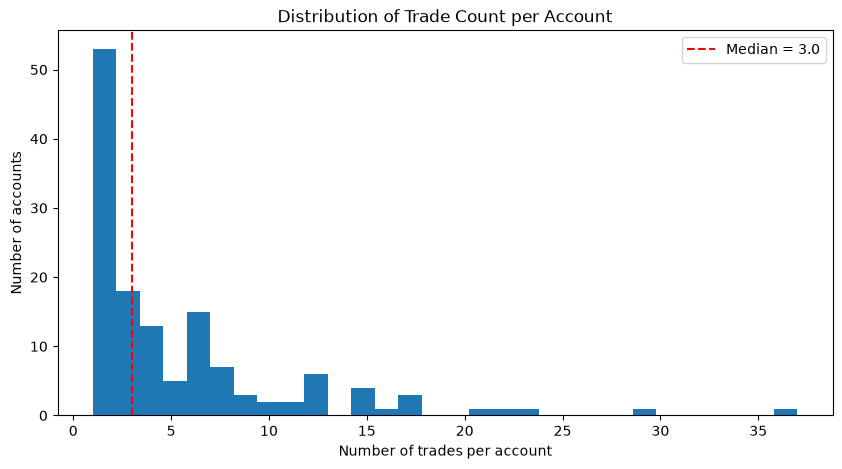

In [92]:
plt.figure(figsize=(10, 5))

plt.hist(
    account_summary["numberOfTrades"],
    bins=30
)

plt.axvline(
    account_summary["numberOfTrades"].median(),
    linestyle="--",
    color="red",
    label=(
        f"Median = "
        f"{account_summary['numberOfTrades'].median():.1f}"
    )
)

plt.xlabel("Number of trades per account")
plt.ylabel("Number of accounts")
plt.title("Distribution of Trade Count per Account")
plt.legend()
plt.show()

### Zoom in the skewed distribution

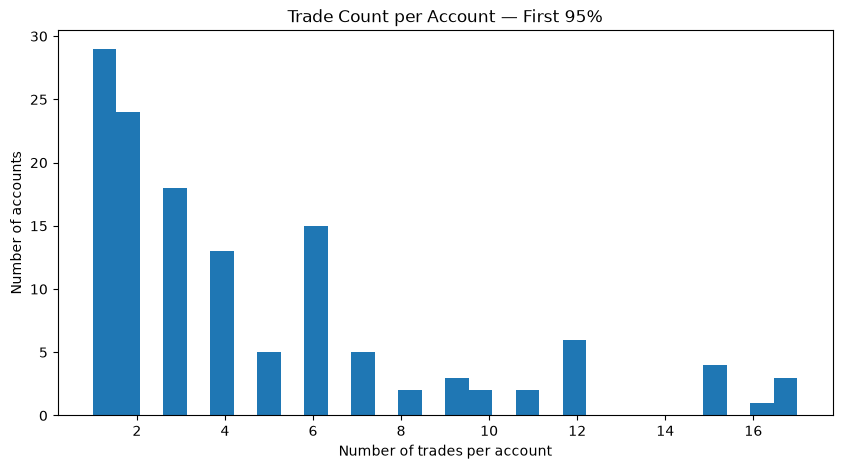

In [93]:
trade_count_95 = (
    account_summary["numberOfTrades"]
    .quantile(0.95)
)

plt.figure(figsize=(10, 5))

plt.hist(
    account_summary.loc[
        account_summary["numberOfTrades"] <= trade_count_95,
        "numberOfTrades"
    ],
    bins=30
)

plt.xlabel("Number of trades per account")
plt.ylabel("Number of accounts")
plt.title("Trade Count per Account — First 95%")
plt.show()

## Trader and reverse profit by account

### Plot total trader profit

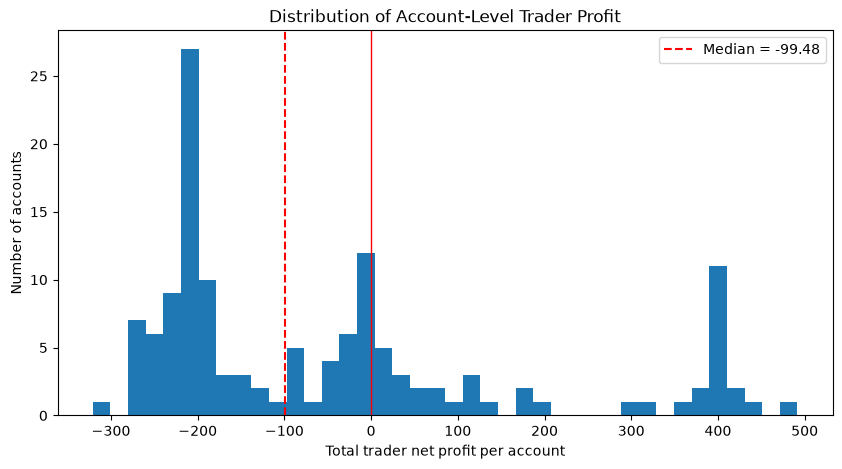

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    account_summary["totalNetProfit"],
    bins=40
)

plt.axvline(0, linewidth=1, color="red")

plt.axvline(
    account_summary["totalNetProfit"].median(),
    linestyle="--",
    color="red",
    label=(
        f"Median = "
        f"{account_summary['totalNetProfit'].median():.2f}"
    )
)

plt.xlabel("Total trader net profit per account")
plt.ylabel("Number of accounts")
plt.title("Distribution of Account-Level Trader Profit")
plt.legend()
plt.show()

### Plot total reverse profit

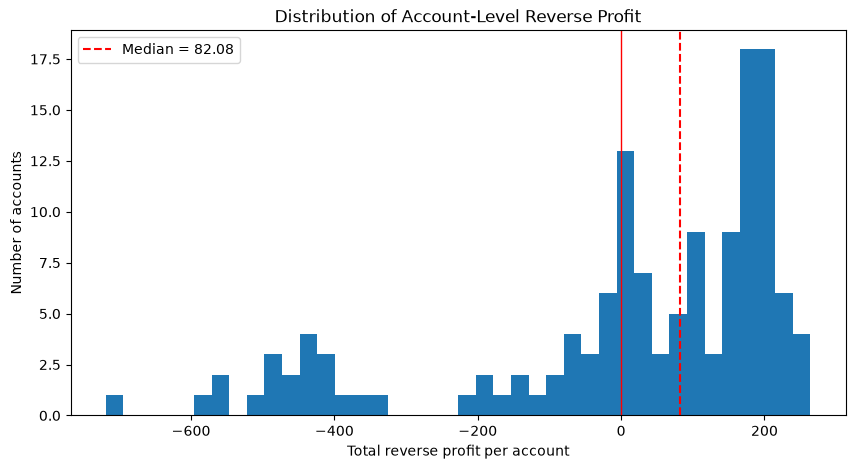

In [97]:
plt.figure(figsize=(10, 5))

plt.hist(
    account_summary["totalReverseProfit"],
    bins=40
)

plt.axvline(0, linewidth=1, color="red")

plt.axvline(
    account_summary["totalReverseProfit"].median(),
    linestyle="--",
    color="red",
    label=(
        f"Median = "
        f"{account_summary['totalReverseProfit'].median():.2f}"
    )
)

plt.xlabel("Total reverse profit per account")
plt.ylabel("Number of accounts")
plt.title("Distribution of Account-Level Reverse Profit")
plt.legend()
plt.show()

### Count profitable accounts

In [100]:
account_profitability = pd.Series({
    "number_of_accounts":
        len(account_summary),

    "trader_profitable_accounts":
        (account_summary["totalNetProfit"] > 0).sum(),

    "trader_loss_accounts":
        (account_summary["totalNetProfit"] < 0).sum(),

    "reverse_profitable_accounts":
        (account_summary["totalReverseProfit"] > 0).sum(),

    "reverse_loss_accounts":
        (account_summary["totalReverseProfit"] < 0).sum(),

    "reverse_profitable_account_rate":
        (account_summary["totalReverseProfit"] > 0).mean(),

    "trader_profitable_account_rate":
        (account_summary["totalNetProfit"] > 0).mean()
})

print(account_profitability)

number_of_accounts                 137.000000
trader_profitable_accounts          46.000000
trader_loss_accounts                91.000000
reverse_profitable_accounts         89.000000
reverse_loss_accounts               48.000000
reverse_profitable_account_rate      0.649635
trader_profitable_account_rate       0.335766
dtype: float64


## Profit concentration

### Rank accounts by reverse profit

In [119]:
account_summary_ranked = (
    account_summary
    .sort_values(
        "totalReverseProfit",
        ascending=False
    )
    .copy()
)

account_summary_ranked["cumulativeReverseProfit"] = (
    account_summary_ranked["totalReverseProfit"]
    .cumsum()
)

total_positive_reverse_profit = (
    account_summary_ranked.loc[
        account_summary_ranked["totalReverseProfit"] > 0,
        "totalReverseProfit"
    ].sum()
)

account_summary_ranked["cumulativeReverseProfitShare"] = (
    account_summary_ranked["cumulativeReverseProfit"]
    / total_positive_reverse_profit
)

print(
    account_summary_ranked[
        [
            "accountId",
            "numberOfTrades",
            "totalNetProfit",
            "totalReverseProfit",
            "cumulativeReverseProfitShare"
        ]
    ].head(10)
)

     accountId  numberOfTrades  totalNetProfit  totalReverseProfit  \
61   D#1702422               2         -268.27              264.05   
113  D#1702661               1         -272.26              258.39   
85   D#1702519               1         -266.80              250.00   
90   D#1702536               3         -255.26              240.55   
120  D#1702685               2         -248.49              222.86   
130  D#1702718               5         -265.06              221.77   
54   D#1702376               1         -222.51              220.40   
1    D#1589408               3         -254.62              219.75   
119  D#1702679               3         -229.87              217.25   
115  D#1702663               3         -237.80              216.80   

     cumulativeReverseProfitShare  
61                       0.020886  
113                      0.041324  
85                       0.061099  
90                       0.080126  
120                      0.097754  
130          

### Top-account contribution

In [104]:
positive_account_reverse_profit = (
    account_summary.loc[
        account_summary["totalReverseProfit"] > 0,
        "totalReverseProfit"
    ].sum()
)

top_5_account_reverse_profit = (
    account_summary.nlargest(
        5,
        "totalReverseProfit"
    )["totalReverseProfit"].sum()
)

top_10_account_reverse_profit = (
    account_summary.nlargest(
        10,
        "totalReverseProfit"
    )["totalReverseProfit"].sum()
)

account_concentration_summary = pd.Series({
    "total_reverse_profit":
        account_summary["totalReverseProfit"].sum(),

    "positive_reverse_profit":
        positive_account_reverse_profit,

    "top_5_account_reverse_profit":
        top_5_account_reverse_profit,

    "top_10_account_reverse_profit":
        top_10_account_reverse_profit,

    "top_5_share_of_positive_profit":
        (
            top_5_account_reverse_profit
            / positive_account_reverse_profit
            if positive_account_reverse_profit != 0
            else np.nan
        ),

    "top_10_share_of_positive_profit":
        (
            top_10_account_reverse_profit
            / positive_account_reverse_profit
            if positive_account_reverse_profit != 0
            else np.nan
        )
})

print(account_concentration_summary)

total_reverse_profit                1438.630000
positive_reverse_profit            12642.490000
top_5_account_reverse_profit        1235.850000
top_10_account_reverse_profit       2331.820000
top_5_share_of_positive_profit         0.097754
top_10_share_of_positive_profit        0.184443
dtype: float64


## Profit per trade

### Create profit-per-trade metrics

In [105]:
account_summary["reverseProfitPerTrade"] = (
    account_summary["totalReverseProfit"]
    / account_summary["numberOfTrades"]
)

account_summary["traderProfitPerTrade"] = (
    account_summary["totalNetProfit"]
    / account_summary["numberOfTrades"]
)

In [106]:
print(
    account_summary[
        [
            "reverseProfitPerTrade",
            "traderProfitPerTrade"
        ]
    ].describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    ).T
)

                       count       mean        std     min        1%       5%  \
reverseProfitPerTrade  137.0  16.328164  81.254267 -394.80 -205.5888 -104.388   
traderProfitPerTrade   137.0 -21.768879  81.411690 -272.26 -250.8556 -153.998   

                          25%    50%    75%      95%       99%     max  
reverseProfitPerTrade -14.950  13.18  48.95  150.048  239.3440  258.39  
traderProfitPerTrade  -53.012 -18.11  12.91  101.229  197.4512  378.00  


### Plot reverse profit per trade

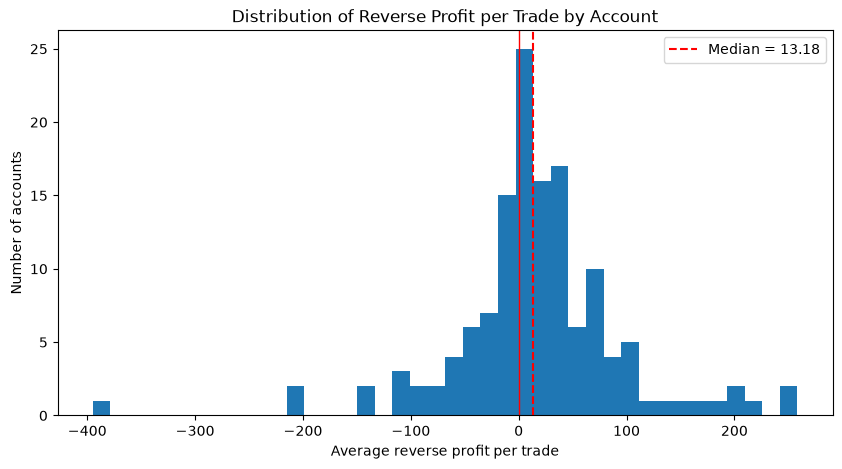

In [108]:
plt.figure(figsize=(10, 5))

plt.hist(
    account_summary["reverseProfitPerTrade"],
    bins=40
)

plt.axvline(0, linewidth=1, color="red")

plt.axvline(
    account_summary[
        "reverseProfitPerTrade"
    ].median(),
    linestyle="--",
    color="red",
    label=(
        f"Median = "
        f"{account_summary['reverseProfitPerTrade'].median():.2f}"
    )
)

plt.xlabel("Average reverse profit per trade")
plt.ylabel("Number of accounts")
plt.title("Distribution of Reverse Profit per Trade by Account")
plt.legend()
plt.show()

## Relationship between activity and profit

### Trade count vs total reverse profit

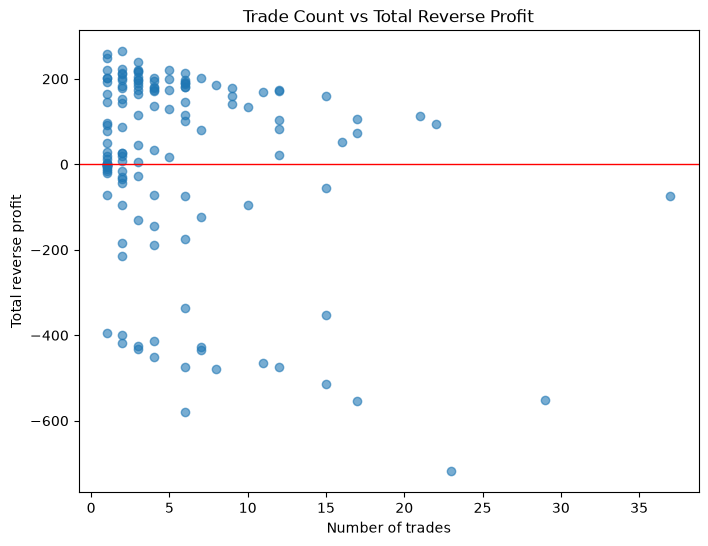

In [110]:
plt.figure(figsize=(8, 6))

plt.scatter(
    account_summary["numberOfTrades"],
    account_summary["totalReverseProfit"],
    alpha=0.6
)

plt.axhline(0, linewidth=1, color="red")

plt.xlabel("Number of trades")
plt.ylabel("Total reverse profit")
plt.title("Trade Count vs Total Reverse Profit")
plt.show()

### Correlation

In [ ]:
trade_count_reverse_correlations = pd.Series({
    # Measures approximately linear relationships
    "pearson_correlation":
        account_summary[
            [
                "numberOfTrades",
                "totalReverseProfit"
            ]
        ].corr(method="pearson").iloc[0, 1],
        
    # Measures monotonic rank relationships, less sensitive to extreme values
    "spearman_correlation":
        account_summary[
            [
                "numberOfTrades",
                "totalReverseProfit"
            ]
        ].corr(method="spearman").iloc[0, 1],
})

print(trade_count_reverse_correlations)

pearson_correlation    -0.273807
spearman_correlation   -0.120066
dtype: float64


### Trade count vs reverse profit per trade

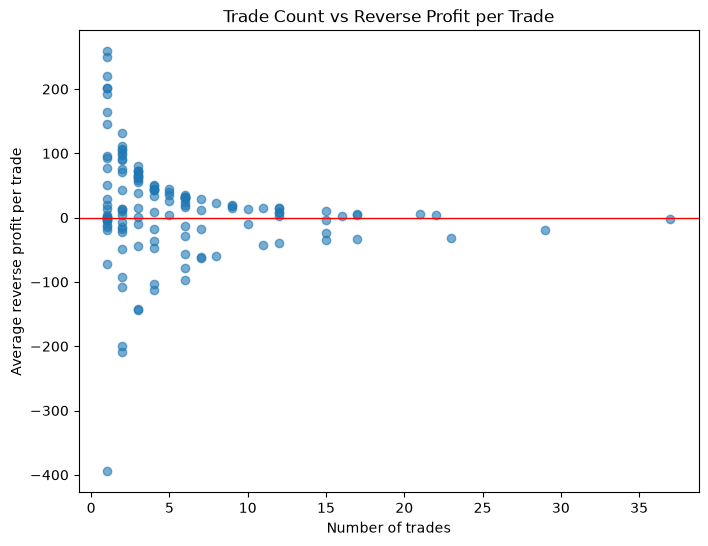

In [112]:
plt.figure(figsize=(8, 6))

plt.scatter(
    account_summary["numberOfTrades"],
    account_summary["reverseProfitPerTrade"],
    alpha=0.6
)

plt.axhline(0, linewidth=1, color="red")

plt.xlabel("Number of trades")
plt.ylabel("Average reverse profit per trade")
plt.title("Trade Count vs Reverse Profit per Trade")
plt.show()

### Correlation

In [114]:
print(
    account_summary[
        [
            "numberOfTrades",
            "reverseProfitPerTrade"
        ]
    ].corr(method="spearman").iloc[0, 1]
)

-0.2623102850522899


## Trader profit vs reverse profit by account

### Plot the relationship

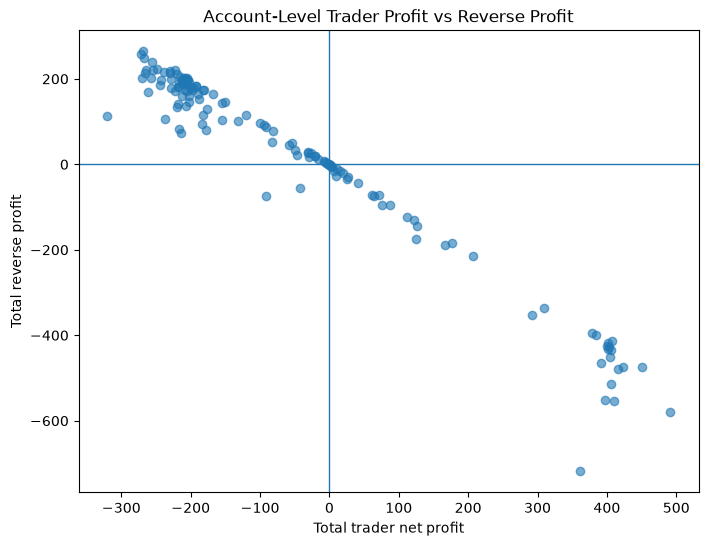

In [115]:
plt.figure(figsize=(8, 6))

plt.scatter(
    account_summary["totalNetProfit"],
    account_summary["totalReverseProfit"],
    alpha=0.6
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Total trader net profit")
plt.ylabel("Total reverse profit")
plt.title("Account-Level Trader Profit vs Reverse Profit")
plt.show()

### Correlation

In [117]:
account_profit_correlation = (
    account_summary[
        [
            "totalNetProfit",
            "totalReverseProfit"
        ]
    ]
    .corr(method="pearson").iloc[0,1]
)

print(account_profit_correlation)

-0.9781805323625657


## Four account-level outcomes

In [118]:
account_conditions = [
    (
        (account_summary["totalNetProfit"] > 0)
        & (account_summary["totalReverseProfit"] > 0)
    ),
    (
        (account_summary["totalNetProfit"] > 0)
        & (account_summary["totalReverseProfit"] <= 0)
    ),
    (
        (account_summary["totalNetProfit"] <= 0)
        & (account_summary["totalReverseProfit"] > 0)
    ),
    (
        (account_summary["totalNetProfit"] <= 0)
        & (account_summary["totalReverseProfit"] <= 0)
    )
]

account_choices = [
    "Both profitable",
    "Trader profitable, reverse not profitable",
    "Trader not profitable, reverse profitable",
    "Neither profitable"
]

account_summary["accountOutcomeGroup"] = np.select(
    account_conditions,
    account_choices,
    default="Unknown"
)

account_outcome_summary = (
    account_summary["accountOutcomeGroup"]
    .value_counts()
    .to_frame("number_of_accounts")
)

account_outcome_summary["percentage"] = (
    account_outcome_summary["number_of_accounts"]
    / len(account_summary)
)

print(account_outcome_summary)

                                           number_of_accounts  percentage
accountOutcomeGroup                                                      
Trader not profitable, reverse profitable                  89    0.649635
Trader profitable, reverse not profitable                  46    0.335766
Neither profitable                                          2    0.014599


## Initial account-level observations

1. Trading activity is highly concentrated, with most accounts placing relatively few trades and a small number of accounts trading much more frequently.
2. Account-level reverse profit is right-skewed, and the mean is materially different from the median.
3. A positive overall reverse profit does not imply that most accounts are profitable to reverse.
4. A limited number of accounts contribute a substantial proportion of positive reverse profit.
5. Total reverse profit is partly related to trade count, so profit-per-trade should be considered alongside aggregate profit.